### Veeresh Mulge
* 2nd Year Student from Dayananda Sagar College of Engineering
* Robotics and Artificial Intelligence Department
* Linkdin: www.linkedin.com/in/veeresh-mulge


# Capstone Project 1

### Importing required Libraries

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, pearsonr, spearmanr
import pandas as pd
import urllib.request

In [55]:
male_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"
female_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

# Define the local filenames
male_filename = "nhanes_adult_male_bmx_2020.csv"
female_filename = "nhanes_adult_female_bmx_2020.csv"

### Reading the two files as numpy matrices

In [70]:
# Load the CSV files, skipping the 18 rows of metadata headers
male = np.genfromtxt(male_filename, delimiter=",", skip_header=19)
female = np.genfromtxt(female_filename, delimiter=",", skip_header=19)

In [57]:
print(female)

[[ 97.1 160.2  34.7 ...  35.8 126.1 117.9]
 [ 91.1 152.7  33.5 ...  38.5 125.5 103.1]
 [ 73.  161.2  37.4 ...  31.8 106.2  92. ]
 ...
 [ 73.  159.6  36.2 ...  31.4 104.6  99.3]
 [ 78.6 168.5  38.1 ...  36.  102.4  98.5]
 [ 82.8 147.8  34.8 ...  39.5 121.4 110. ]]


In [58]:
print(male)

[[ 98.8 182.3  42.  ...  38.2 108.2 120.4]
 [ 74.3 184.2  41.1 ...  30.2  94.5  86.8]
 [103.7 185.3  47.  ...  32.  107.8 109.6]
 ...
 [108.8 168.7  38.6 ...  33.6 118.  114.7]
 [ 79.5 176.4  39.5 ...  31.4  99.8  97.1]
 [ 59.7 167.5  40.3 ...  29.2  90.5  86.9]]


### Drawing two histograms for female weight and male weight

In [59]:
female_weights = female[:, 0]
male_weights = male[:, 0]

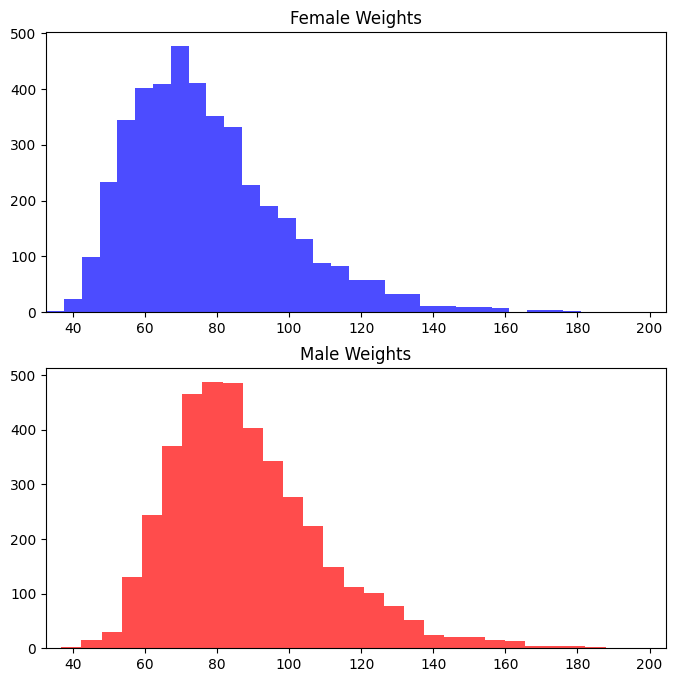

In [83]:
min_w = np.nanmin([np.nanmin(female_weights), np.nanmin(male_weights)])
max_w = np.nanmax([np.nanmax(female_weights), np.nanmax(male_weights)])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.hist(female_weights, bins=30, color='blue', alpha=0.7)
ax1.set_title("Female Weights")
ax1.set_xlim([min_w, max_w])

ax2.hist(male_weights, bins=30, color='red', alpha=0.7)
ax2.set_title("Male Weights")
ax2.set_xlim([min_w, max_w])
plt.show()

### Drawing Box and whisker plot showing the male and female weigths for comparison

/tmp/ipykernel_800/3901484772.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([female_weights[~np.isnan(female_weights)],


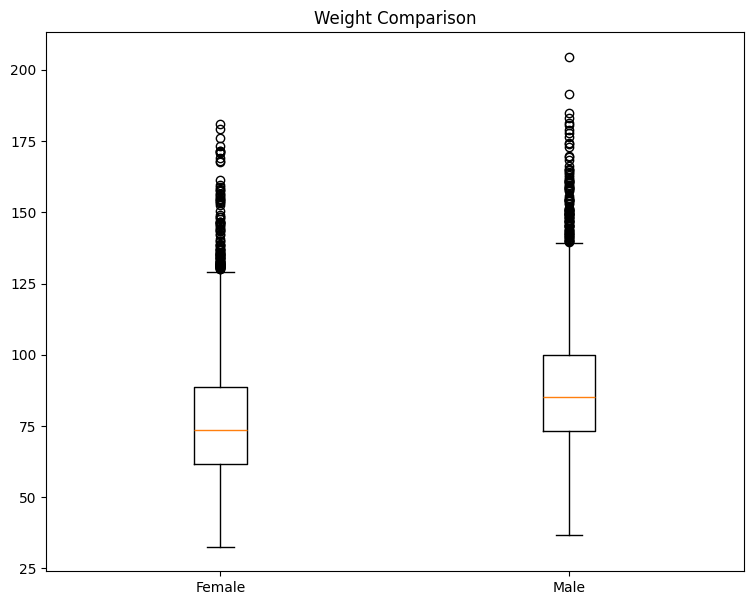

In [61]:
plt.figure(figsize=(9, 7))
plt.boxplot([female_weights[~np.isnan(female_weights)],
             male_weights[~np.isnan(male_weights)]],
            labels=['Female', 'Male'])
plt.title("Weight Comparison")
plt.show()

### Basic numerical aggregates of male and female weights

In [62]:
female_weights = female[:, 0]
male_weights = male[:, 0]

female_mean = np.mean(female_weights)
female_median = np.median(female_weights)
female_std = np.std(female_weights)
female_var = np.var(female_weights)
female_sk = skew(female_weights)

male_mean = np.mean(male_weights)
male_median = np.median(male_weights)
male_std = np.std(male_weights)
male_var = np.var(male_weights)
male_sk = skew(male_weights)

print("--- Female Weight Statistics ---")
print(f"Location: '\n' Mean: {female_mean} kg | '\n' Median: {female_median} kg")
print(f"Dispersion: '\n' Std Dev: {female_std} kg | '\n' Variance: {female_var} kg^2")
print(f"Shape: '\n' Skewness: {female_sk}")

print("\n--- Male Weight Statistics ---")
print(f"Location: '\n' Mean: {male_mean} kg | '\n' Median: {male_median} kg")
print(f"Dispersion: '\n' Std Dev: {male_std} kg | '\n' Variance: {male_var} kg^2")
print(f"Shape: '\n' Skewness: {male_sk}")


--- Female Weight Statistics ---
Location: '
' Mean: 77.40379057095475 kg | '
' Median: 73.6 kg
Dispersion: '
' Std Dev: 21.54250829019315 kg | '
' Variance: 464.07966343304065 kg^2
Shape: '
' Skewness: 1.03336107186799

--- Male Weight Statistics ---
Location: '
' Mean: 88.36454300416565 kg | '
' Median: 85.0 kg
Dispersion: '
' Std Dev: 21.418936717962495 kg | '
' Variance: 458.770850128082 kg^2
Shape: '
' Skewness: 0.9842810741662347


## Observations based on calculations

* We observe that the men are heavier than female with a mean weight of 88.36 kg and 77.40 kg respectively.
* The median weights are also on the scale of 85 kg and 73.6 kg for male and female respectively.
* Both groups give a standard deviation of 21.4 and 21.5 which are nearly same.
* The spread of the data is also nearly identical between the two groups.
* Both distributions are right skewed as the calculation of skewness is positive, but the female data is more right skewed "1.03" which is higher than the male data "0.98".

### Adding a column to the female matrix which gives the body mass indices of all female participants

In [63]:
female_weight = female[:, 0]
female_height_cm = female[:, 1]

# Converting female height from cm to m
female_height_m = female_height_cm / 100

# Calculating bmi using the formula
female_bmi = female_weight / (female_height_m ** 2)

# Reshaping the 1D BMI array into 2D column vector so it can be stacked
female_bmi = female_bmi.reshape(-1, 1)

# Adding the bmi column to the female matrix
female_with_bmi = np.column_stack((female, female_bmi))

print(female_with_bmi)

[[ 97.1        160.2         34.7        ... 126.1        117.9
   37.83504078]
 [ 91.1        152.7         33.5        ... 125.5        103.1
   39.06972037]
 [ 73.         161.2         37.4        ... 106.2         92.
   28.09265496]
 ...
 [ 73.         159.6         36.2        ... 104.6         99.3
   28.65873958]
 [ 78.6        168.5         38.1        ... 102.4         98.5
   27.68361084]
 [ 82.8        147.8         34.8        ... 121.4        110.
   37.90368801]]


### A new matrix zfemale being a version of the female dataset with all its columns standardised

In [82]:
zfemale = (female_with_bmi - np.mean(female_with_bmi, axis=0)) / np.std(female_with_bmi, axis=0)
print(np.round(zfemale, 3))

[[ 9.140e-01  9.000e-03 -5.670e-01 ...  1.083e+00  1.116e+00  9.970e-01]
 [ 6.360e-01 -1.053e+00 -1.079e+00 ...  1.045e+00  2.650e-01  1.156e+00]
 [-2.040e-01  1.510e-01  5.840e-01 ... -1.910e-01 -3.730e-01 -2.590e-01]
 ...
 [-2.040e-01 -7.600e-02  7.200e-02 ... -2.930e-01  4.700e-02 -1.860e-01]
 [ 5.600e-02  1.184e+00  8.820e-01 ... -4.340e-01  1.000e-03 -3.120e-01]
 [ 2.500e-01 -1.747e+00 -5.250e-01 ...  7.820e-01  6.620e-01  1.006e+00]]


### Drawing the scatterplot for the standardised version

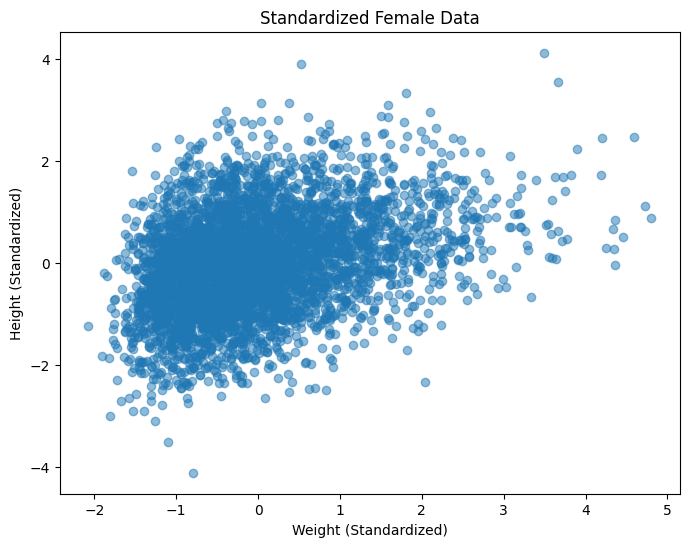

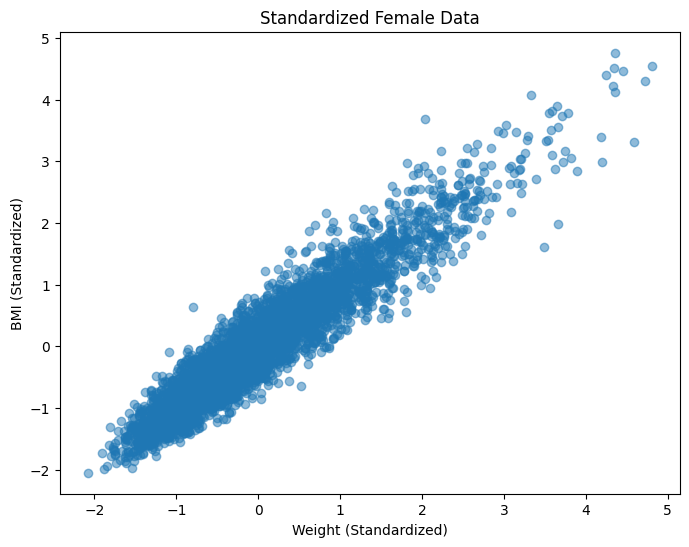

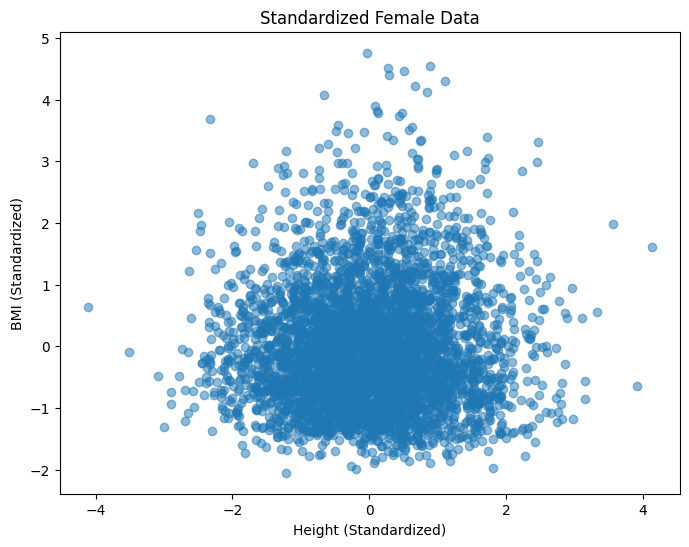

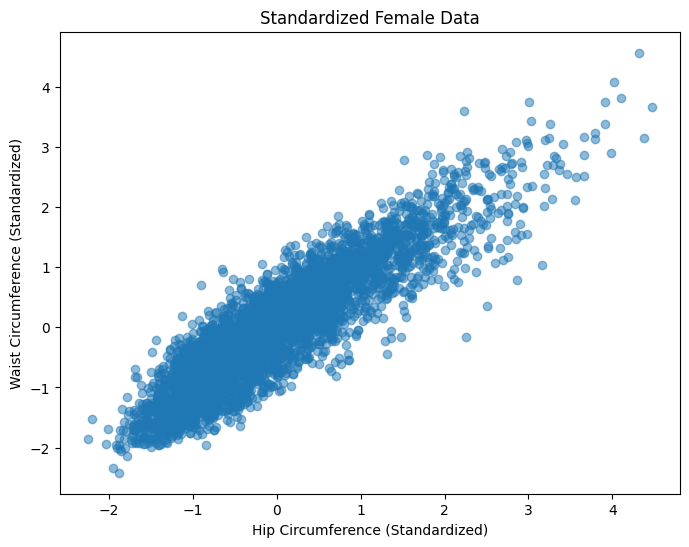

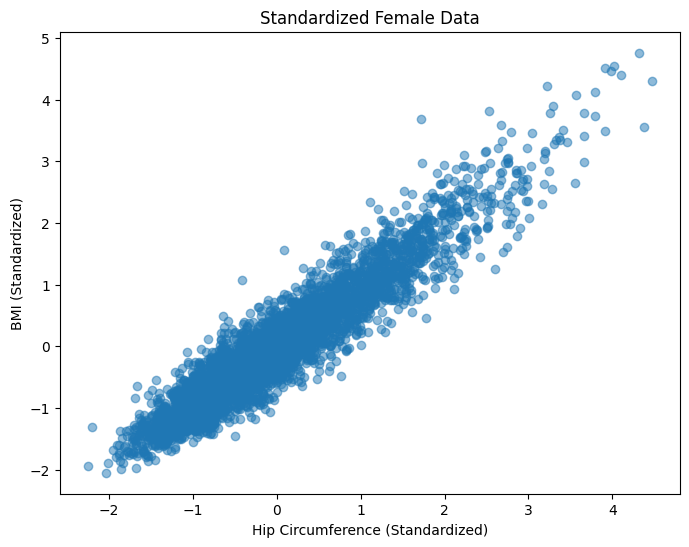

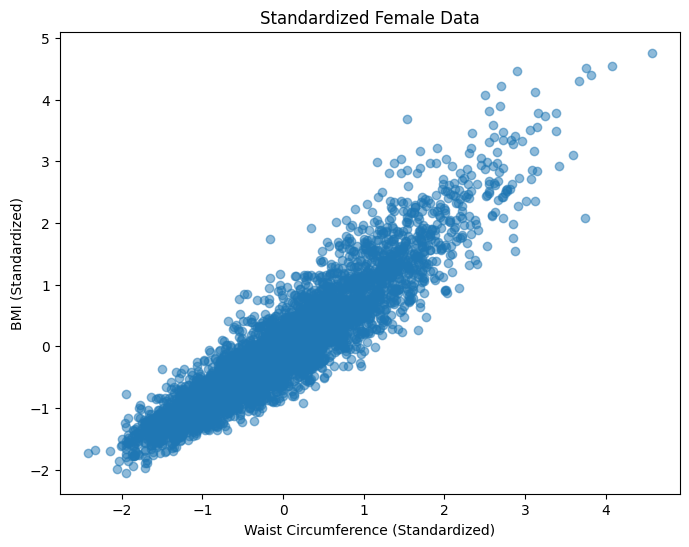

In [65]:
plt.figure(figsize=(8, 6))
plt.scatter(zfemale[:, 0], zfemale[:, 1], alpha=0.5)
plt.title("Standardized Female Data")
plt.xlabel("Weight (Standardized)")
plt.ylabel("Height (Standardized)")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(zfemale[:, 0], zfemale[:, 7], alpha=0.5)
plt.title("Standardized Female Data")
plt.xlabel("Weight (Standardized)")
plt.ylabel("BMI (Standardized)")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(zfemale[:, 1], zfemale[:, 7], alpha=0.5)
plt.title("Standardized Female Data")
plt.xlabel("Height (Standardized)")
plt.ylabel("BMI (Standardized)")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(zfemale[:, 5], zfemale[:, 6], alpha=0.5)
plt.title("Standardized Female Data")
plt.xlabel("Hip Circumference (Standardized)")
plt.ylabel("Waist Circumference (Standardized)")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(zfemale[:, 5], zfemale[:, 7], alpha=0.5)
plt.title("Standardized Female Data")
plt.xlabel("Hip Circumference (Standardized)")
plt.ylabel("BMI (Standardized)")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(zfemale[:, 6], zfemale[:, 7], alpha=0.5)
plt.title("Standardized Female Data")
plt.xlabel("Waist Circumference (Standardized)")
plt.ylabel("BMI (Standardized)")
plt.show()


### Compute Pearson’s and Spearman’s correlation coefficients for all pairs of variables.

In [77]:
w_female = female[:, 0]
h_female = female[:, 1]
waist_female = female[:, 6]
hip_female = female[:, 5]
bmi_female = w_female / ((h_female / 100) ** 2)

data = np.column_stack((w_female, h_female, waist_female, hip_female, bmi_female))

df = pd.DataFrame(data, columns = ["Weight", "Height", "Waist", "Hip", "BMI"])

pearson_corr = df.corr(method='pearson')
spearman_corr = df.corr(method='spearman')

print("Pearson Correlation Matrix:\n", pearson_corr.round(3))
print("\nSpearman Correlation Matrix:\n", spearman_corr.round(3))

Pearson Correlation Matrix:
         Weight  Height  Waist    Hip    BMI
Weight   1.000   0.345  0.905  0.947  0.946
Height   0.345   1.000  0.127  0.203  0.033
Waist    0.905   0.127  1.000  0.897  0.921
Hip      0.947   0.203  0.897  1.000  0.944
BMI      0.946   0.033  0.921  0.944  1.000

Spearman Correlation Matrix:
         Weight  Height  Waist    Hip    BMI
Weight   1.000   0.339  0.900  0.947  0.938
Height   0.339   1.000  0.109  0.205  0.020
Waist    0.900   0.109  1.000  0.888  0.923
Hip      0.947   0.205  0.888  1.000  0.934
BMI      0.938   0.020  0.923  0.934  1.000


## Observations

* Pearson correlation measures linear relationships between variables
* Spearman correlation measures monotonic relationships, where variables move in one direction
* According to the data, Weight and BMI have a very strong relation between them in both Pearson and Spearman coefficient with values 0.946 and 0.938 respectively
* According to the data, Height and BMI have very low relation between them (Pearson: 0.033 and Spearman: 0.020) which validates the formula of Body Mass Index, it was created specifically to normalize body weight against the height.


### Compute the waist circumference to height ratio and the waist circumference to hip circumference ratio of the male and female participants by adding two more columns to the males and females matrices.

In [66]:
# Female calculations
# Waist: column 6, Height: column 1, Hip: column 5
f_waist_height = female[:, 6] / female[:, 1]
f_waist_hip = female[:, 6] / female[:, 5]
female = np.column_stack((female, f_waist_height.reshape(-1, 1), f_waist_hip.reshape(-1, 1)))

# Male calculations
m_waist_height = male[:, 6] / male[:, 1]
m_waist_hip = male[:, 6] / male[:, 5]
male = np.column_stack((male, m_waist_height.reshape(-1, 1), m_waist_hip.reshape(-1, 1)))

In [67]:
female.shape

(4221, 9)

In [68]:
male.shape

(4081, 9)

In [69]:
female_with_bmi.shape

(4221, 8)

### Box-and-whisker plot


/tmp/ipykernel_800/1561933107.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([f_waist_height, m_waist_height, f_waist_hip, m_waist_hip], labels=["Female Waist to Height", "Male Waist to Height", "Female Waist to Hip", "Male Waist to Hip"])


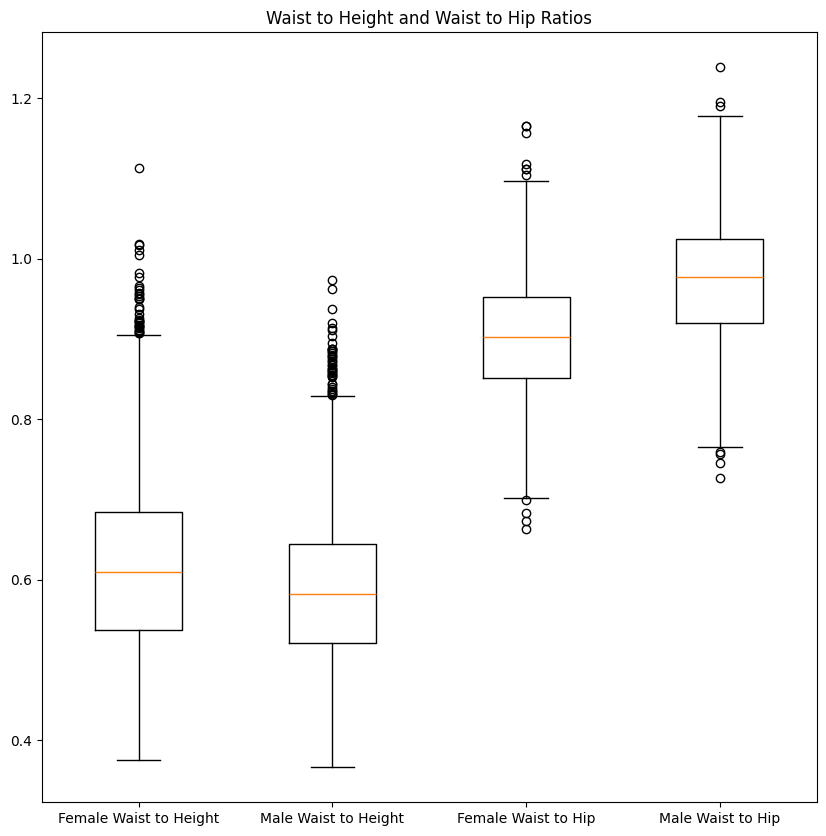

In [79]:
plt.figure(figsize=(10, 10))
plt.boxplot([f_waist_height, m_waist_height, f_waist_hip, m_waist_hip], labels=["Female Waist to Height", "Male Waist to Height", "Female Waist to Hip", "Male Waist to Hip"])
plt.title("Waist to Height and Waist to Hip Ratios")
plt.show()

### Advantages of BMI

* Requires only weight and height measurements
* Helps doctors to find out potential health risks like heart disease and diabetes
* Does not require any lab or expensive Equipments

### Disadvantages of BMI

* Cannot tell difference between heavy body muscle and body fat
* Does not show where fat is stored, such as dangerous fat around organs
* Muscular people or bodybuilders may be registered as overweight or obese

### Advantages of Waist-to-Height Ratio

* Keep your waist size less than half of your height
* Finds hidden belly fat even in people with a normal weight
* Accurately shows higher chances of high blood pressure and heart failure

### Disadvantages of Waist-to-Height Ratio

* Does not measure muscle mass or overall body frame size
* Does not separate deep organ fat to regular skin fat
* Should not be used for children under age six


### Advantages of Waist-to-Hip Ratio

* It is a stronger indicator of metabolic risk and chronic disease than basic weight or BMI
* It specifically identifies apple-shaped fat distribution, which poses higher risks for cardiovascular issues.
* It requires only a basic tape measure and simple math to perform at home

### Disadvantages of Waist-to-Hip Ratio

* It cannot tell the difference between extra hip fat and high muscle mass around the hips from exercise.
* It is not accurate or useful for children, people under 5 feet tall, or individuals with a BMI of 35 or higher
* Taking two separate measurements can lead to human error in placement or posture

### Standardised body measurements for 5 persons with lowest and highest BMI

In [81]:
zfemale = (female_with_bmi - np.mean(female_with_bmi, axis=0)) / np.std(female_with_bmi, axis=0)

sorted_indices = np.argsort(zfemale[:, 7])

lowest_5 = zfemale[sorted_indices[:5]]
highest_5 = zfemale[sorted_indices[-5:]]

print("Lowest 5 BMI:")
print(np.round(lowest_5, 3))

print("\nHighest 5 BMI:")
print(np.round(highest_5, 3))

Lowest 5 BMI:
[[-2.08  -1.223 -1.548 -1.169 -2.195 -2.041 -1.942 -2.05 ]
 [-1.88  -0.189 -1.718  0.386 -2.444 -1.855 -2.057 -1.995]
 [-1.537  1.807  0.626  0.573 -2.266 -1.676 -1.706 -1.971]
 [-1.843 -0.26  -0.226  0.511 -2.302 -2.252 -1.856 -1.942]
 [-1.611  0.887 -0.098  0.48  -2.213 -1.829 -1.712 -1.893]]

Highest 5 BMI:
[[ 4.247  0.292  1.862 -0.982  2.369  4.104  3.817  4.396]
 [ 4.456  0.505  1.692 -1.138  3.35   3.983  2.903  4.462]
 [ 4.349  0.278  2.843  1.942  4.366  3.919  3.754  4.515]
 [ 4.804  0.887  2.118  1.817  3.778  4.021  4.082  4.543]
 [ 4.363 -0.034 -0.056 -0.174  2.779  4.316  4.57   4.762]]


# References

* About Pearson and Spearman correlation coefficient from Geeks for Geeks: https://www.geeksforgeeks.org/maths/pearson-vs-spearman-correlation-coefficient/
* About BMI from Wikipedia: https://en.wikipedia.org/wiki/Body_mass_index
* About Advantages and Disadvantages of BMI, Waist-to-Height and Waist-to-Hip Ratio from National Institute of Health: https://www.nih.gov/
* Code related doubts from Google and Gemini